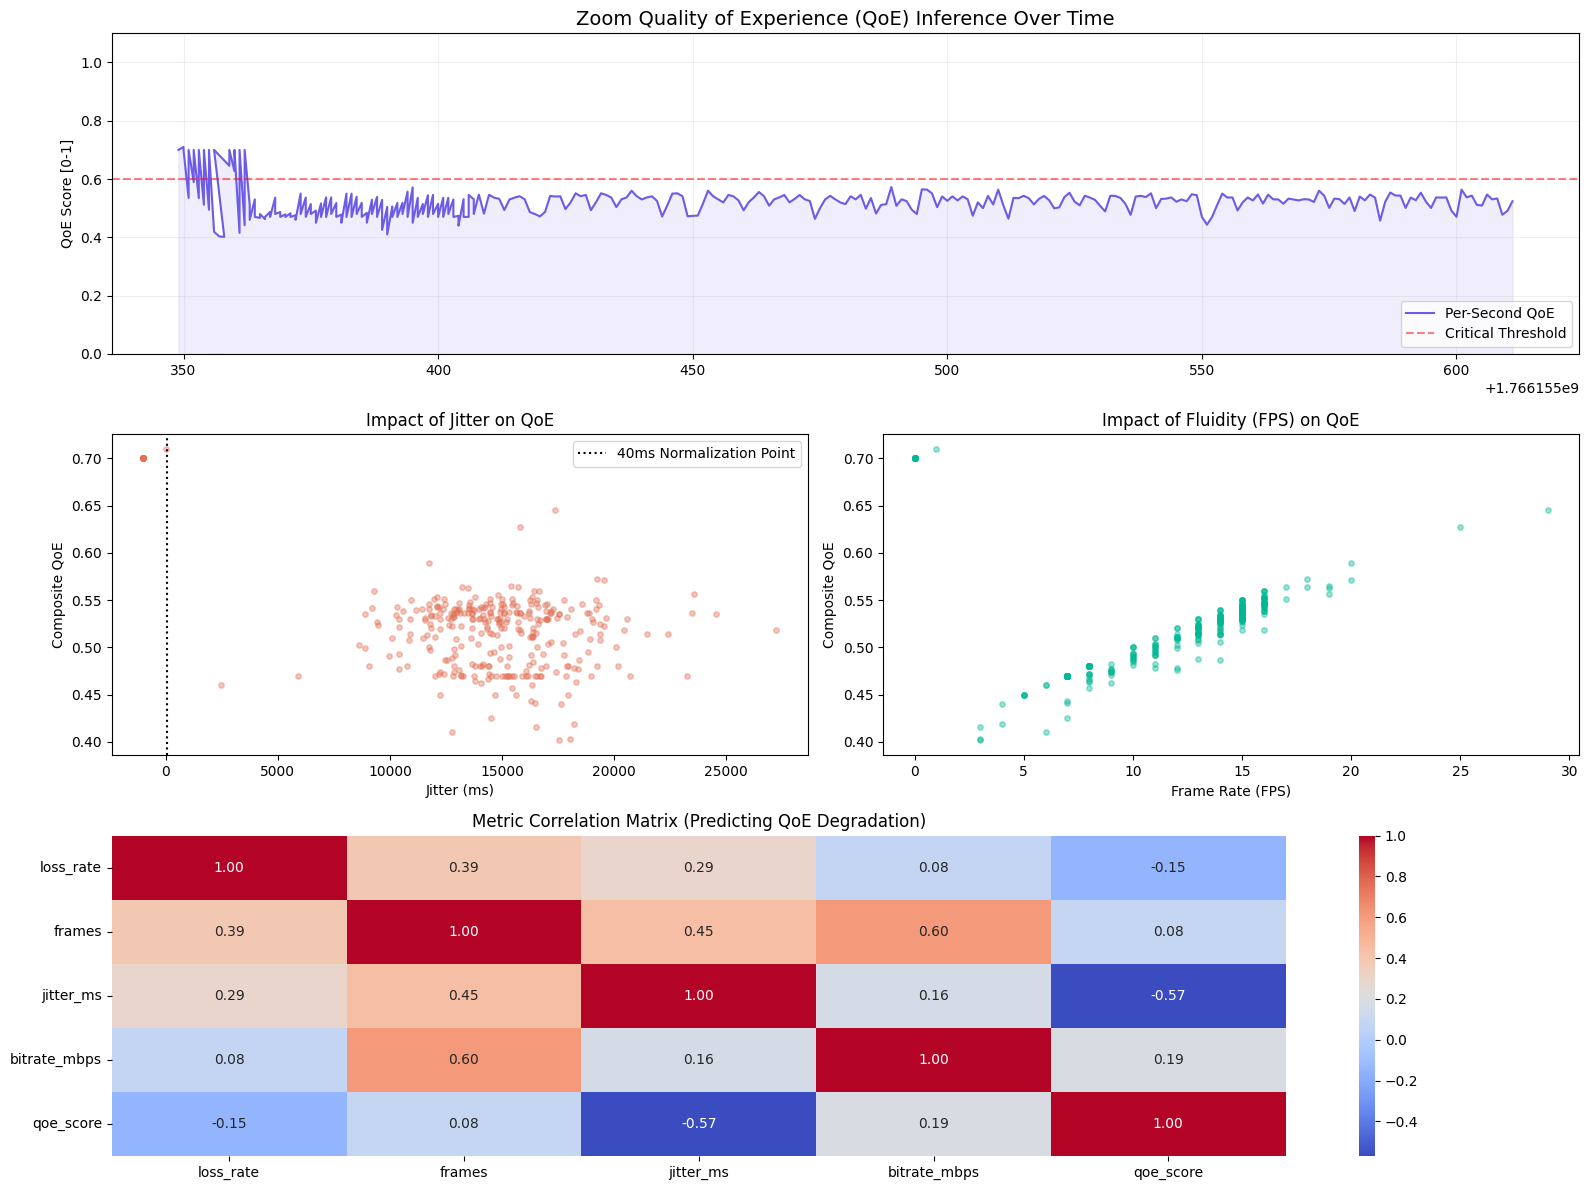


QoE MEASUREMENT SUMMARY
Mean QoE Score: 0.5224
QoE Variance:   0.0026
Time under 0.6: 304 seconds


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Added for correlation heatmap

# 1. LOAD AND CLEAN DATA
df = pd.read_csv("stats.csv")
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. BASE METRIC CALCULATION
# Loss Rate (L) - Normalized 0 to 1
df["loss_rate"] = df["lost"] / (df["pkts"] + df["lost"] + 1e-10)
df["loss_rate"] = df["loss_rate"].clip(0, 1)

# Bitrate (Mbps) for reference
if 'bytes' in df.columns:
    df['bitrate_mbps'] = (df['bytes'] * 8) / 1e6

# Jitter (J) in ms
if 'mean_jitter' in df.columns:
    df['jitter_ms'] = df['mean_jitter'] * 1000

# 3. QoE SCORE CALCULATION (Step 2: Model Layer)
# Weights (w1, w2, w3) - Adjustable based on priority (continuity vs fluidity)
w1, w2, w3 = 0.4, 0.3, 0.3

# f(frame rate) = FPS / 30
df['f_fps'] = (df['frames'] / 30).clip(0, 1)

# g(loss) = 1 - Loss
df['g_loss'] = (1 - df['loss_rate'])

# h(jitter) = 1 - (Jitter / 40ms)
df['h_jitter'] = (1 - (df['jitter_ms'] / 40)).clip(0, 1)

# Composite Formula: QoE = w1*g(loss) + w2*f(fps) + w3*h(jitter)
df['qoe_score'] = (w1 * df['g_loss']) + (w2 * df['f_fps']) + (w3 * df['h_jitter'])

# 4. MEASUREMENT ANALYSIS (Step 3 Preview: Correlation)
# This calculates how strongly each network metric drives the final QoE
correlation_cols = ['loss_rate', 'frames', 'jitter_ms', 'bitrate_mbps', 'qoe_score']
corr_matrix = df[correlation_cols].corr()

# 5. VISUALIZATION
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2)

# Plot 1: QoE Score Timeline
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['ts_s'], df['qoe_score'], color='#6c5ce7', linewidth=1.5, label='Per-Second QoE')
ax1.fill_between(df['ts_s'], df['qoe_score'], 0, alpha=0.1, color='#6c5ce7')
ax1.axhline(0.6, color='red', linestyle='--', alpha=0.5, label='Critical Threshold')
ax1.set_title('Zoom Quality of Experience (QoE) Inference Over Time', fontsize=14)
ax1.set_ylabel('QoE Score [0-1]')
ax1.set_ylim(0, 1.1)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.2)

# Plot 2: Jitter vs QoE Scatter (Showing the 'Penalty')
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(df['jitter_ms'], df['qoe_score'], alpha=0.4, s=15, color='#e17055')
ax2.axvline(40, color='black', linestyle=':', label='40ms Normalization Point')
ax2.set_xlabel('Jitter (ms)')
ax2.set_ylabel('Composite QoE')
ax2.set_title('Impact of Jitter on QoE')
ax2.legend()

# Plot 3: FPS vs QoE
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(df['frames'], df['qoe_score'], alpha=0.4, s=15, color='#00b894')
ax3.set_xlabel('Frame Rate (FPS)')
ax3.set_ylabel('Composite QoE')
ax3.set_title('Impact of Fluidity (FPS) on QoE')

# Plot 4: Correlation Heatmap (Step 3 Requirement)
ax4 = fig.add_subplot(gs[2, :])
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=ax4, fmt=".2f")
ax4.set_title('Metric Correlation Matrix (Predicting QoE Degradation)')

plt.tight_layout()
plt.savefig('zoom_measurement_results.png', dpi=200)
plt.show()

# 6. EXPORTING FOR PAPER TABLES
print("\n" + "="*30)
print("QoE MEASUREMENT SUMMARY")
print("="*30)
print(f"Mean QoE Score: {df['qoe_score'].mean():.4f}")
print(f"QoE Variance:   {df['qoe_score'].var():.4f}")
print(f"Time under 0.6: {len(df[df['qoe_score'] < 0.6])} seconds")
print("="*30)

df.to_csv("qoe_processed_results.csv", index=False)